# 04 — Error Analysis: LightGBM, Random Forest, XGBoost

`03_model_extension.ipynb` found LightGBM the clear leader (PR-AUC 0.245), with Random Forest and
XGBoost tied a step behind (0.229 each). Aggregate metrics can't say *where* each model succeeds
or fails, or whether the two runners-up are making the same mistakes as the leader or genuinely
different ones -- which is exactly what decides whether an ensemble is worth trying later. This
notebook does that: segment-level performance, confusion-matrix error types, cross-model error
overlap, feature-importance comparison, and a qualitative look at specific missed/caught clients.

Per the sequencing agreed with the team, this happens **before** any hyperparameter tuning --
it's cheap (reuses the same out-of-fold predictions as `03`, no new modelling ideas needed to
start), and its findings should decide what gets tuned and whether ensembling is worth trying,
rather than tuning blind.

## Imports and constants

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

pd.set_option("display.max_columns", 100)

DATA_DIR = Path("data")
PROCESSED_DIR = DATA_DIR / "processed"
TRAIN_FEATURES_PATH = PROCESSED_DIR / "train_client_features.csv"

RSEED = 42  # same seed 01_eda.ipynb / 02_baseline_model.ipynb / 03_model_extension.ipynb use
N_SPLITS = 5
TOP_K_SHARE = 0.10  # same capacity slice as 02 and 03, so "flagged" means the same thing here

if not TRAIN_FEATURES_PATH.exists():
    raise FileNotFoundError(
        f"Missing {TRAIN_FEATURES_PATH}. Run 01_eda.ipynb with SAVE_CSV_FILE=true first "
        "to produce the cleaned, client-level feature table this notebook loads."
    )

## Step 1 — Load the cleaned, client-level features

In [2]:
df = pd.read_csv(TRAIN_FEATURES_PATH)
df["client_id"] = df["client_id"].astype("string")
df["target"] = df["target"].astype("int8")

expected_columns = {
    "client_id", "target",
    "invoice_count", "active_days", "mean_consumption", "zero_consumption_rate",
    "elec_share", "mean_invoice_gap_days", "backwards_index_rate", "meter_count",
    "mean_monthly_submission_index_delta", "backward_submission_rate",
    "large_mismatch_count", "reconciliation_gap_abs_mean",
    "client_catg", "disrict", "region",
}
missing_columns = sorted(expected_columns - set(df.columns))
if missing_columns:
    raise ValueError(f"{TRAIN_FEATURES_PATH} is missing required baseline columns: {missing_columns}")

overview = pd.DataFrame({
    "rows": [len(df)], "unique_clients": [df["client_id"].nunique()], "fraud_rate": [df["target"].mean()],
})
display(overview)

,rows,unique_clients,fraud_rate
0,108394,108394,0.055843


## Step 2 — Preprocessing (identical to `02`/`03`)

This notebook uses the same finalized 15-input contract as the baseline and model extension: 12 numeric features plus the categorical codes `client_catg`, `disrict`, and `region`. Raw dates, tenure, identifiers, and investigation-related fields are not model inputs. Numeric values are median-imputed and scaled; categories are one-hot encoded inside the cross-validation pipeline.

In [3]:
categorical_features = ["client_catg", "region", "disrict"]
numeric_features = [
    "invoice_count", "active_days", "mean_consumption", "zero_consumption_rate",
    "elec_share", "mean_invoice_gap_days", "backwards_index_rate", "meter_count",
    "mean_monthly_submission_index_delta", "backward_submission_rate",
    "large_mismatch_count", "reconciliation_gap_abs_mean",
]

model_features = numeric_features + categorical_features
X = df[model_features]
y = df["target"]
y_values = y.to_numpy()

preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), numeric_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RSEED)

## Step 3 — Recompute out-of-fold predictions for the three tree ensembles

Same model configurations as `03_model_extension.ipynb` (same `class_weight`/`scale_pos_weight`,
same seed, same CV) -- duplicated rather than imported so this notebook runs on its own. Only
the three tree ensembles are needed here; logistic regression, KNN, and Isolation Forest already
have their story from `03` and aren't the subject of this analysis.

In [4]:
scale_pos_weight = (y == 0).sum() / (y == 1).sum()

model_specs = {
    "lightgbm": LGBMClassifier(class_weight="balanced", random_state=RSEED, n_jobs=-1, verbosity=-1),
    "random_forest": RandomForestClassifier(class_weight="balanced", random_state=RSEED, n_jobs=-1),
    "xgboost": XGBClassifier(
        scale_pos_weight=scale_pos_weight, eval_metric="logloss", random_state=RSEED, n_jobs=-1
    ),
}

oof_probas = {}
for name, model in model_specs.items():
    pipeline = Pipeline([("preprocess", preprocessor), ("model", model)])
    oof_probas[name] = cross_val_predict(pipeline, X, y, cv=cv, method="predict_proba")[:, 1]
    print(f"done: {name}")

done: lightgbm


done: random_forest


done: xgboost


## Step 4 — Confusion matrix at the top-10% cutoff

Each model gets its own threshold (the score at its own 90th percentile) -- the same
capacity-aware framing as `02`/`03`, since the three models' raw scores aren't on comparable
scales.

In [5]:
k = int(np.ceil(TOP_K_SHARE * len(y_values)))

flags = {}
thresholds = {}
confusion_rows = {}
for name, proba in oof_probas.items():
    threshold = np.sort(proba)[::-1][k - 1]
    flagged = proba >= threshold
    flags[name] = flagged
    thresholds[name] = threshold

    true_positive = int((flagged & (y_values == 1)).sum())
    false_positive = int((flagged & (y_values == 0)).sum())
    false_negative = int((~flagged & (y_values == 1)).sum())
    true_negative = int((~flagged & (y_values == 0)).sum())
    confusion_rows[name] = {
        "true_positive": true_positive, "false_positive": false_positive,
        "false_negative": false_negative, "true_negative": true_negative,
        "precision_at_k": true_positive / (true_positive + false_positive),
        "recall_at_k": true_positive / (true_positive + false_negative),
    }

confusion_summary = pd.DataFrame(confusion_rows).T
display(confusion_summary)

,true_positive,false_positive,false_negative,true_negative,precision_at_k,recall_at_k
lightgbm,2611.0,8229.0,3442.0,94112.0,0.240867,0.431356
random_forest,2622.0,8713.0,3431.0,93628.0,0.231319,0.433174
xgboost,2523.0,8317.0,3530.0,94024.0,0.232749,0.416818


## Step 5 — Segment-level performance

Recall and precision computed *within* each segment, using the same top-10% flags from Step 4 --
this is where a strong overall score can hide a weak or unfair segment (README guardrail #7).
The invoice-count quintiles are the same bins the EDA used for the observation-window-bias
finding, now asking the model-relevant version of that question: does the model *also* catch
less fraud among short-history clients, not just "is the label rarer there." 

Recall/precision by client_catg:


,segment,clients,fraud_cases,lightgbm_recall,lightgbm_precision,random_forest_recall,random_forest_precision,xgboost_recall,xgboost_precision
0,11,105216,5758,0.424800,0.238588,0.426711,0.229134,0.417506,0.230489
2,51,1299,220,0.686364,0.314583,0.700000,0.303150,0.500000,0.325444
1,12,1879,75,0.186667,0.129630,0.146667,0.105769,0.120000,0.125000


Recall/precision by disrict:


,segment,clients,fraud_cases,lightgbm_recall,lightgbm_precision,random_forest_recall,random_forest_precision,xgboost_recall,xgboost_precision
3,69,27391,1943,0.338137,0.211935,0.365414,0.199887,0.346886,0.191586
1,62,32336,1682,0.424495,0.236502,0.424495,0.221464,0.399524,0.235955
2,63,23207,1506,0.565737,0.309144,0.575033,0.300590,0.537849,0.300892
0,60,25460,922,0.420824,0.197455,0.360087,0.197855,0.398048,0.205948


Recall/precision by region (top 15 by fraud case count):


,segment,clients,fraud_cases,lightgbm_recall,lightgbm_precision,random_forest_recall,random_forest_precision,xgboost_recall,xgboost_precision
0,101,26938,977,0.417605,0.198637,0.358240,0.198300,0.399181,0.207226
16,311,9966,800,0.693750,0.352157,0.673750,0.350911,0.641250,0.350649
1,103,7144,734,0.501362,0.229283,0.505450,0.222689,0.505450,0.207843
2,104,10319,569,0.231986,0.203390,0.256591,0.171362,0.235501,0.170483
5,107,7990,524,0.250000,0.192647,0.312977,0.193625,0.282443,0.187579
8,303,4821,265,0.449057,0.231068,0.422642,0.222664,0.422642,0.235789
6,301,7646,249,0.248996,0.197452,0.345382,0.195900,0.285141,0.179747
11,306,4841,225,0.333333,0.237342,0.435556,0.235012,0.400000,0.235602
9,304,3056,215,0.404651,0.224806,0.409302,0.214112,0.441860,0.238095
7,302,3458,214,0.500000,0.250585,0.467290,0.235294,0.462617,0.255814


Recall/precision by invoice-count quintile:


,segment,clients,fraud_cases,lightgbm_recall,lightgbm_precision,random_forest_recall,random_forest_precision,xgboost_recall,xgboost_precision
4,"(57.0, 380.0]",21448,1933,0.518883,0.250374,0.531816,0.252332,0.486808,0.257808
3,"(36.0, 57.0]",21879,1672,0.467105,0.243682,0.464713,0.233966,0.444378,0.230674
2,"(22.0, 36.0]",21053,1416,0.444915,0.238636,0.438559,0.227556,0.446328,0.225714
1,"(7.0, 22.0]",22301,828,0.235507,0.207006,0.221014,0.182635,0.241546,0.180995
0,"(0.999, 7.0]",21713,204,0.009804,0.042553,0.063725,0.062201,0.034314,0.109375


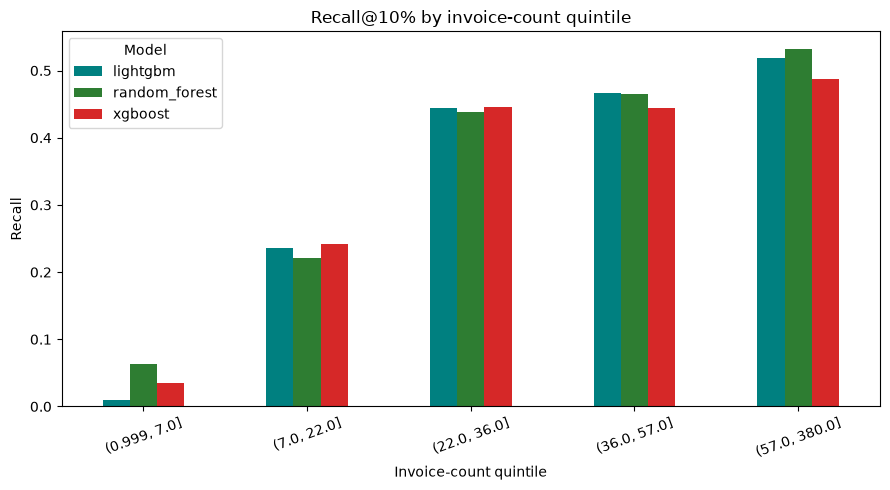

In [6]:
def segment_performance(frame, column, model_names, minimum_clients=50):
    rows = []
    for segment_value, group in frame.groupby(column, dropna=False):
        if len(group) < minimum_clients:
            continue
        fraud_cases = group["target"].sum()
        row = {"segment": segment_value, "clients": len(group), "fraud_cases": fraud_cases}
        for name in model_names:
            flagged = group[f"flagged_{name}"]
            caught = int((flagged & (group["target"] == 1)).sum())
            flagged_count = int(flagged.sum())
            row[f"{name}_recall"] = caught / fraud_cases if fraud_cases > 0 else np.nan
            row[f"{name}_precision"] = caught / flagged_count if flagged_count > 0 else np.nan
        rows.append(row)
    return pd.DataFrame(rows).sort_values("fraud_cases", ascending=False)


analysis = df.copy()
for name, flagged in flags.items():
    analysis[f"flagged_{name}"] = flagged
analysis["invoice_count_quintile"] = pd.qcut(analysis["invoice_count"], q=5, duplicates="drop")

model_names = list(model_specs.keys())

print("Recall/precision by client_catg:")
display(segment_performance(analysis, "client_catg", model_names))

print("Recall/precision by disrict:")
display(segment_performance(analysis, "disrict", model_names))

print("Recall/precision by region (top 15 by fraud case count):")
display(segment_performance(analysis, "region", model_names).head(15))

print("Recall/precision by invoice-count quintile:")
quintile_table = segment_performance(analysis, "invoice_count_quintile", model_names)
display(quintile_table)

recall_columns = [f"{name}_recall" for name in model_names]
plot_table = quintile_table.sort_values("segment").set_index("segment")[recall_columns]
plot_table.columns = model_names
ax = plot_table.plot(kind="bar", figsize=(9, 5), color=["#008080", "#2E7D32", "#D62828"])
ax.set(title="Recall@10% by invoice-count quintile", xlabel="Invoice-count quintile", ylabel="Recall")
ax.legend(title="Model")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Step 6 — Do the three models miss the same fraud, or different fraud?

The question that actually decides whether ensembling is worth trying later: for each fraud
client, count how many of the three models missed them (0 = every model caught them, 3 = every
model missed them). If misses cluster at 0 and 3, the models agree with each other and an
ensemble won't help much. If there's a lot of "missed by exactly 1 or 2," the models are making
different mistakes, and averaging/combining them could genuinely catch more fraud than any one
model alone.

Among all fraud clients, how many of the 3 models missed them:


,fraud_clients
0,1727
1,876
2,823
3,2627



Among all non-fraud clients, how many of the 3 models falsely flagged them:


,non_fraud_clients
0,89166
1,5332
2,3602
3,4241


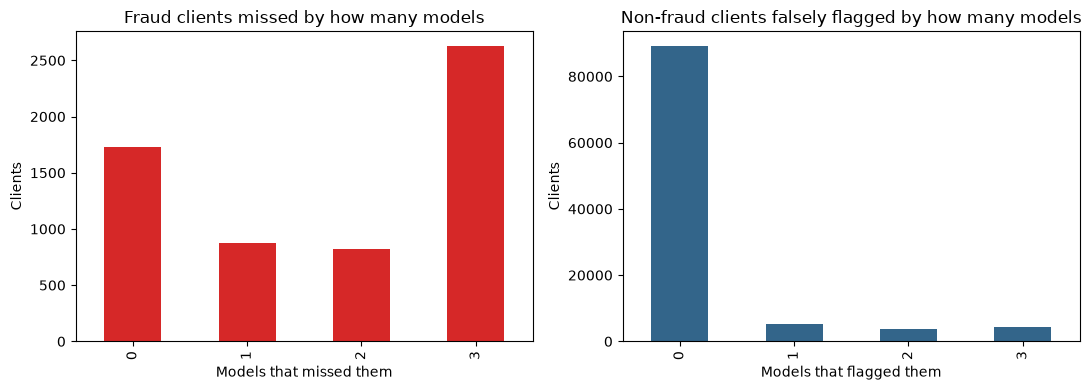

In [7]:
fraud_positions = np.flatnonzero(y_values == 1)
non_fraud_positions = np.flatnonzero(y_values == 0)

missed_by = pd.DataFrame(
    {name: ~flags[name][fraud_positions] for name in model_names}, index=fraud_positions
)
missed_count = missed_by.sum(axis=1)
print("Among all fraud clients, how many of the 3 models missed them:")
display(missed_count.value_counts().sort_index().rename("fraud_clients").to_frame())

falsely_flagged_by = pd.DataFrame(
    {name: flags[name][non_fraud_positions] for name in model_names}, index=non_fraud_positions
)
falsely_flagged_count = falsely_flagged_by.sum(axis=1)
print("\nAmong all non-fraud clients, how many of the 3 models falsely flagged them:")
display(falsely_flagged_count.value_counts().sort_index().rename("non_fraud_clients").to_frame())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
missed_count.value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#D62828")
axes[0].set(title="Fraud clients missed by how many models", xlabel="Models that missed them", ylabel="Clients")
falsely_flagged_count.value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#33658A")
axes[1].set(title="Non-fraud clients falsely flagged by how many models", xlabel="Models that flagged them", ylabel="Clients")
plt.tight_layout()
plt.show()

## Step 7 — Where the models agree and disagree on catching fraud

Step 6 counted *how many* models missed each fraud client; this section shows *which* clients
and *where*. Two views: a client-by-client scatter of each pair of models' scores (colored by
how many models missed that client), and a segment-level breakdown of the same agreement
categories -- then a dedicated close-up on the clients every model misses, since that's the
group we most need to understand.

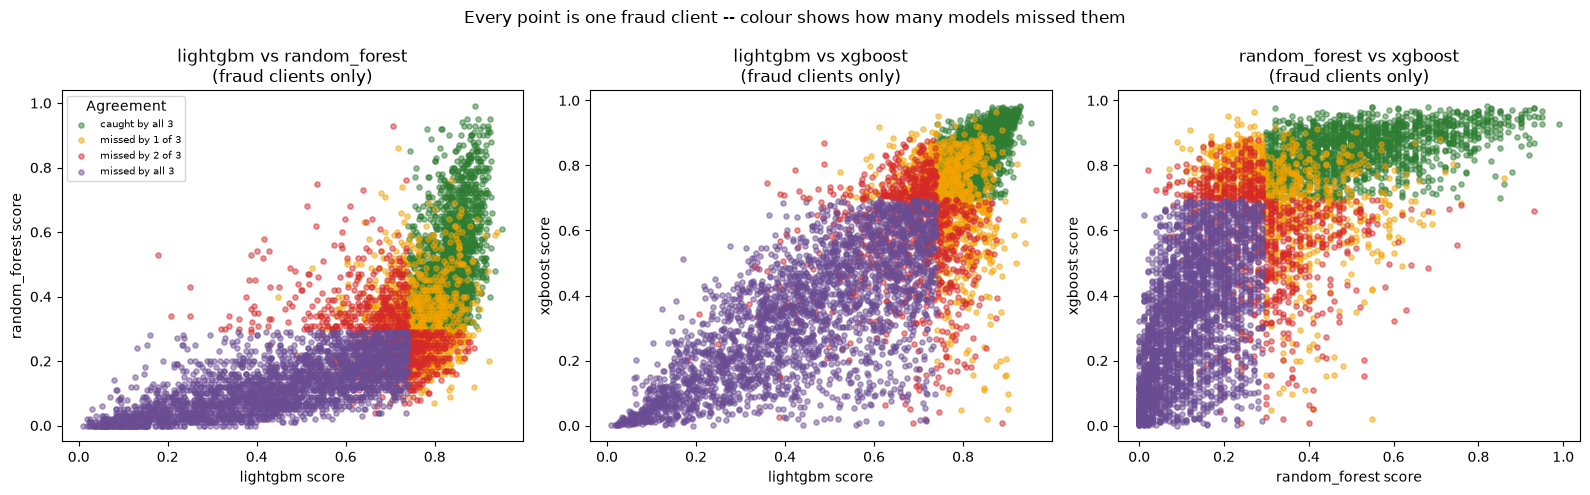

In [8]:
agreement_labels = {
    0: "caught by all 3", 1: "missed by 1 of 3", 2: "missed by 2 of 3", 3: "missed by all 3",
}
fraud_agreement = missed_count.map(agreement_labels)  # index = fraud_positions, from Step 6

palette = {
    "caught by all 3": "#2E7D32", "missed by 1 of 3": "#F4A300",
    "missed by 2 of 3": "#D62828", "missed by all 3": "#6A4C93",
}
agreement_order = list(palette.keys())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pairs = [("lightgbm", "random_forest"), ("lightgbm", "xgboost"), ("random_forest", "xgboost")]
for ax, (model_a, model_b) in zip(axes, pairs):
    for label in agreement_order:
        positions = fraud_agreement[fraud_agreement == label].index
        ax.scatter(oof_probas[model_a][positions], oof_probas[model_b][positions],
                   s=14, alpha=0.5, color=palette[label], label=label)
    ax.set(xlabel=f"{model_a} score", ylabel=f"{model_b} score",
           title=f"{model_a} vs {model_b}\n(fraud clients only)")
axes[0].legend(fontsize=7.5, loc="upper left", title="Agreement")
fig.suptitle("Every point is one fraud client -- colour shows how many models missed them")
plt.tight_layout()
plt.show()

### By segment

The same four agreement categories, now broken down by invoice-count quintile and by
`client_catg` -- do the disagreements and unanimous misses concentrate in particular segments,
or are they spread evenly?

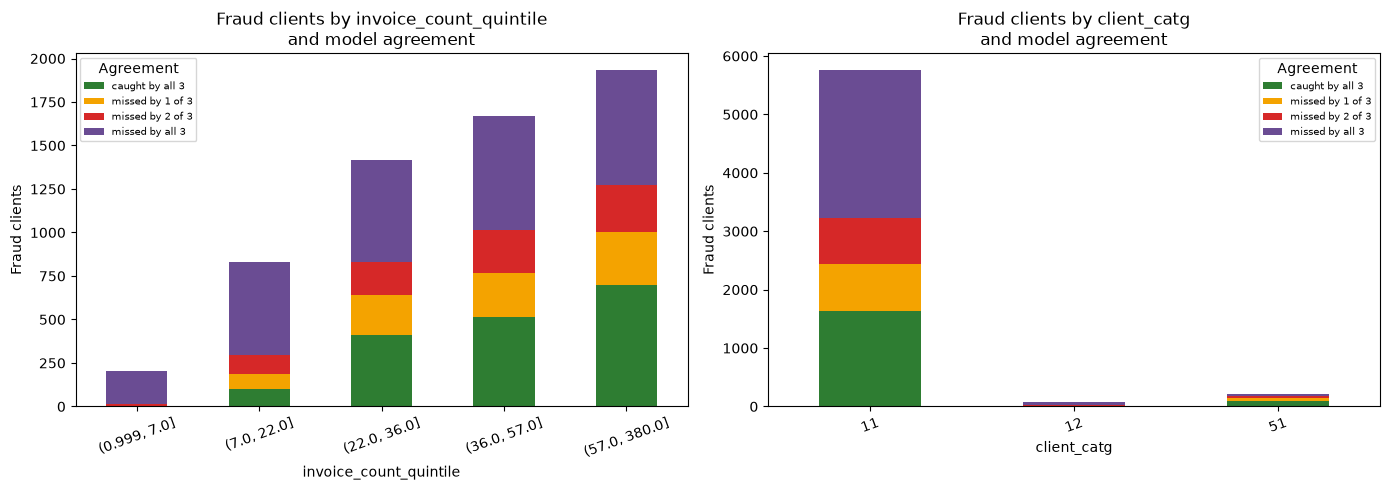

In [9]:
analysis["agreement"] = pd.NA
analysis.loc[fraud_agreement.index, "agreement"] = fraud_agreement.values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, column in zip(axes, ["invoice_count_quintile", "client_catg"]):
    counts = (
        analysis.dropna(subset=["agreement"])
        .groupby([column, "agreement"], observed=True).size()
        .unstack("agreement").reindex(columns=agreement_order)
    )
    counts.plot(kind="bar", stacked=True, ax=ax, color=[palette[c] for c in agreement_order])
    ax.set(title=f"Fraud clients by {column}\nand model agreement", ylabel="Fraud clients")
    ax.legend(fontsize=7, title="Agreement")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

### A closer look at the fraud clients every model misses

Not mixed in with the other categories this time -- just the "missed by all 3" group on its
own, to see concretely where these clients concentrate.

2627 fraud clients missed by all 3 models -- where do they concentrate?


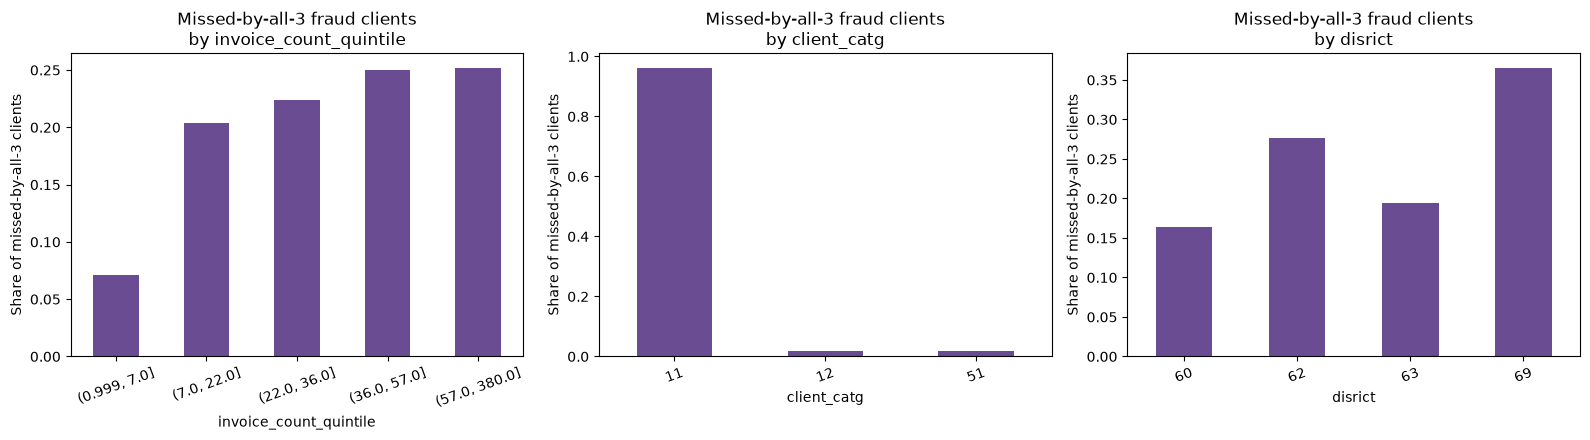

In [10]:
missed_by_all = analysis[analysis["agreement"] == "missed by all 3"]
print(f"{len(missed_by_all)} fraud clients missed by all 3 models -- where do they concentrate?")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, column in zip(axes, ["invoice_count_quintile", "client_catg", "disrict"]):
    missed_by_all[column].value_counts(normalize=True).sort_index().plot(
        kind="bar", ax=ax, color="#6A4C93"
    )
    ax.set(title=f"Missed-by-all-3 fraud clients\nby {column}", ylabel="Share of missed-by-all-3 clients")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## Step 8 — Feature importance comparison

Each model uses a different importance metric internally (LightGBM: split count, XGBoost: gain,
Random Forest: impurity decrease) -- these are **not comparable in magnitude across models**,
only within each model's own ranking. Shown side by side to see whether the three models are
relying on similar signals or genuinely different ones.

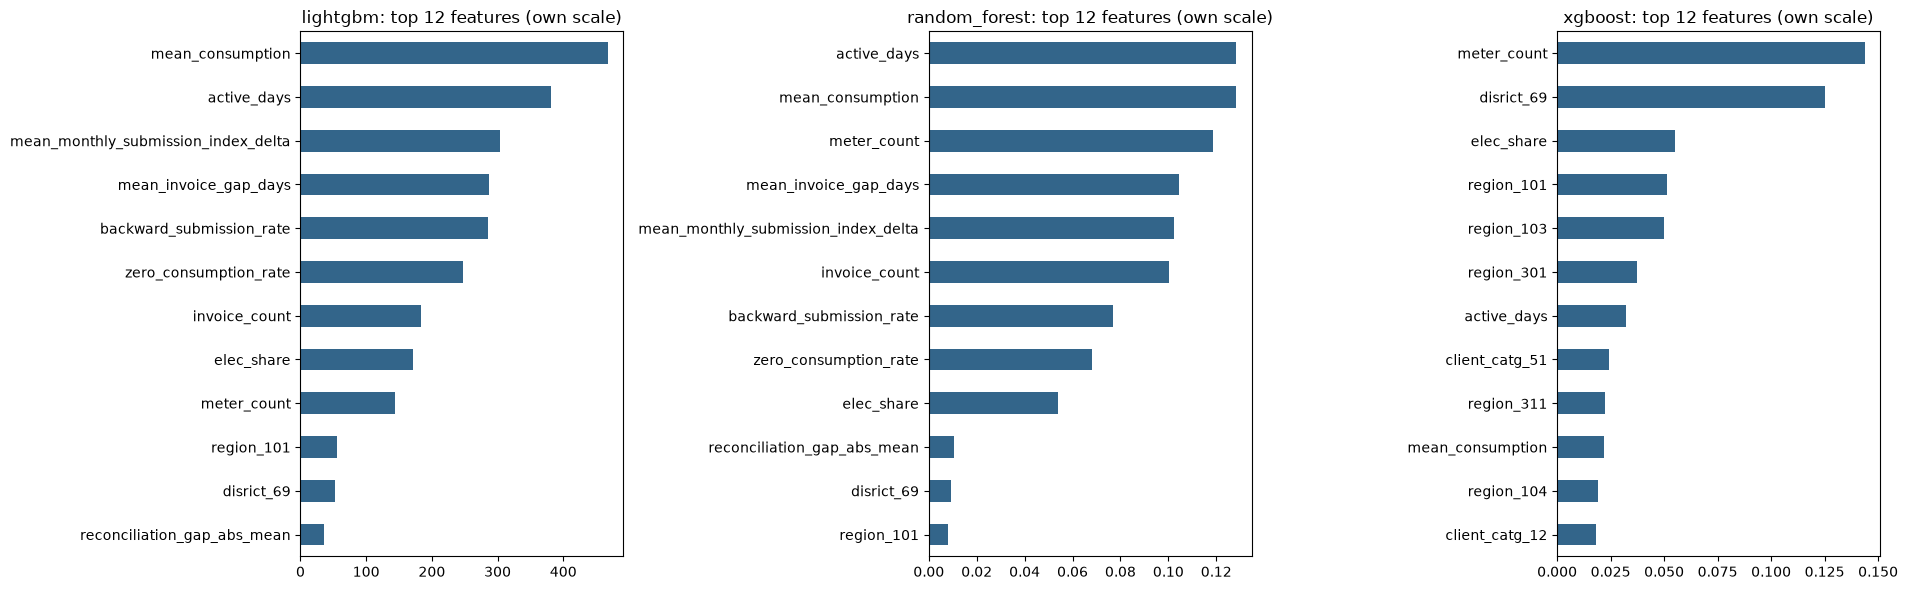

In [11]:
fitted_pipelines = {}
for name, model in model_specs.items():
    pipeline = Pipeline([("preprocess", preprocessor), ("model", model)])
    pipeline.fit(X, y)
    fitted_pipelines[name] = pipeline

feature_names = fitted_pipelines["lightgbm"].named_steps["preprocess"].get_feature_names_out()
feature_names = [name.split("__", 1)[-1] for name in feature_names]

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
for axis, name in zip(axes, model_names):
    importances = fitted_pipelines[name].named_steps["model"].feature_importances_
    top = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(12)
    top.iloc[::-1].plot(kind="barh", ax=axis, color="#33658A")
    axis.set(title=f"{name}: top 12 features (own scale)")
fig.tight_layout()
plt.show()

## Step 9 — A qualitative look at specific clients

A handful of fraud clients every model missed, and a handful every model caught -- not a
statistic, just a sanity-check read on what "hard" and "easy" actually look like here.

In [12]:
inspect_columns = [
    "client_id", "client_catg", "region", "disrict", "invoice_count", "active_days",
    "mean_consumption", "backwards_index_rate", "reconciliation_gap_abs_mean",
]

hardest_positions = missed_count[missed_count == len(model_names)].index
print(f"Fraud clients missed by all {len(model_names)} models: {len(hardest_positions)}")
display(analysis.iloc[hardest_positions][inspect_columns].head(8))

easiest_positions = missed_count[missed_count == 0].index
print(f"\nFraud clients caught by all {len(model_names)} models: {len(easiest_positions)}")
display(analysis.iloc[easiest_positions][inspect_columns].head(8))

Fraud clients missed by all 3 models: 2627


,client_id,client_catg,region,disrict,invoice_count,active_days,mean_consumption,backwards_index_rate,reconciliation_gap_abs_mean
31,train_Client_100032,11,308,63,18,2105,392.555556,0.0,0.0
80,train_Client_100091,11,101,60,43,3065,240.162791,0.0,0.0
97,train_Client_100109,11,312,63,23,2911,394.956522,0.0,0.0
188,train_Client_10022,11,107,69,37,4965,548.783784,0.0,0.0
202,train_Client_100235,11,302,62,9,1004,1292.333333,0.0,0.0
260,train_Client_10030,11,310,62,14,2187,1371.357143,0.0,0.0
281,train_Client_100322,11,104,69,19,3913,821.631579,0.0,0.0
317,train_Client_100362,11,371,62,105,4554,935.647619,0.0,0.0



Fraud clients caught by all 3 models: 1727


,client_id,client_catg,region,disrict,invoice_count,active_days,mean_consumption,backwards_index_rate,reconciliation_gap_abs_mean
152,train_Client_100177,11,306,63,62,5102,264.612903,0.0,0.000000
219,train_Client_100252,11,311,63,77,4819,263.909091,0.0,0.000000
240,train_Client_100277,11,104,69,29,5011,670.448276,0.0,0.000000
282,train_Client_100323,11,310,62,83,5101,244.771084,0.0,0.000000
329,train_Client_100376,11,103,69,36,4851,329.250000,0.0,0.000000
384,train_Client_100439,11,103,69,58,4128,415.137931,0.0,10.465517
421,train_Client_100481,11,311,63,56,4846,359.071429,0.0,0.000000
488,train_Client_10056,11,101,60,38,2195,154.552632,0.0,0.000000


## Step 10 — How much of the 42.4% miss rate is the known short-history story, versus something else?

Step 7 found that 2,563 fraud clients (42.4% of all fraud) are missed by every model. Step 5
already showed the shortest invoice-count quintile collapses to 2.0-3.4% recall -- plausibly a
large share of that 2,563 is just the observation-window blind spot restated. This step separates
the two: which quintile bin(s) are actually collapsed (data-driven, not assumed), what fraction
of the missed-by-all group they explain, and -- for the *rest* of the missed group (long-history
clients still missed by every model) -- how far below each model's own top-10% threshold they
actually score. A client just under the line is a capacity/threshold problem; a client scored low
with confidence is a features problem.

,segment,clients,fraud_cases,lightgbm_recall,random_forest_recall,xgboost_recall,max_recall
0,"(0.999, 7.0]",21713,204,0.009804,0.063725,0.034314,0.063725
1,"(7.0, 22.0]",22301,828,0.235507,0.221014,0.241546,0.241546
2,"(22.0, 36.0]",21053,1416,0.444915,0.438559,0.446328,0.446328
3,"(36.0, 57.0]",21879,1672,0.467105,0.464713,0.444378,0.467105
4,"(57.0, 380.0]",21448,1933,0.518883,0.531816,0.486808,0.531816


Quintile bin(s) already explained by the known short-history blind spot (max recall across models < 10%): {Interval(0.999, 7.0, closed='right')}

2627 fraud clients missed by all 3 models, split by history bucket:


,clients,share_of_missed_%
history_bucket,,
long history (unexplained),2440,92.9
short history (explained),187,7.1



Among 5,849 long-history fraud clients, 41.7% are still missed by every model -- the residual puzzle once the known short-history blind spot is accounted for.


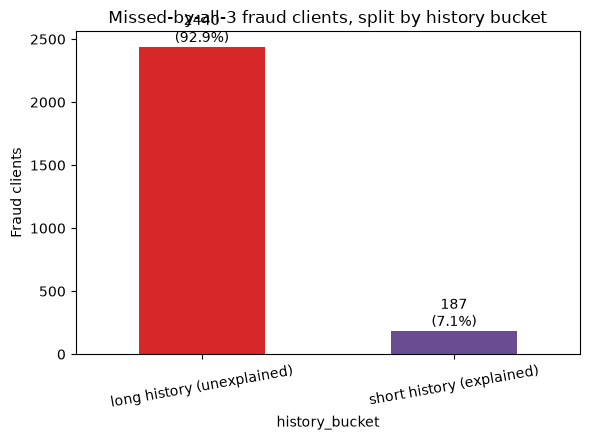

In [13]:
quintile_recall_cols = [f"{name}_recall" for name in model_names]
quintile_by_segment = quintile_table.sort_values("segment").reset_index(drop=True)
quintile_by_segment["max_recall"] = quintile_by_segment[quintile_recall_cols].max(axis=1)
display(quintile_by_segment[["segment", "clients", "fraud_cases"] + quintile_recall_cols + ["max_recall"]])

COLLAPSED_RECALL_THRESHOLD = 0.10  # a quintile bin counts as "already known short-history blind spot"
                                     # if every model's recall there is below this
collapsed_bins = set(
    quintile_by_segment.loc[quintile_by_segment["max_recall"] < COLLAPSED_RECALL_THRESHOLD, "segment"]
)
print(f"Quintile bin(s) already explained by the known short-history blind spot "
      f"(max recall across models < {COLLAPSED_RECALL_THRESHOLD:.0%}): {collapsed_bins}")

analysis["history_bucket"] = np.where(
    analysis["invoice_count_quintile"].isin(collapsed_bins),
    "short history (explained)",
    "long history (unexplained)",
)

missed_by_all = missed_by_all.copy()
missed_by_all["history_bucket"] = analysis.loc[missed_by_all.index, "history_bucket"]

missed_split = missed_by_all["history_bucket"].value_counts()
missed_split_pct = (missed_split / len(missed_by_all) * 100).round(1)
print(f"\n{len(missed_by_all)} fraud clients missed by all 3 models, split by history bucket:")
display(pd.DataFrame({"clients": missed_split, "share_of_missed_%": missed_split_pct}))

long_history_fraud = analysis[(analysis["target"] == 1) & (analysis["history_bucket"] == "long history (unexplained)")]
long_history_missed_rate = (long_history_fraud["agreement"] == "missed by all 3").mean()
print(
    f"\nAmong {len(long_history_fraud):,} long-history fraud clients, "
    f"{long_history_missed_rate:.1%} are still missed by every model -- "
    "the residual puzzle once the known short-history blind spot is accounted for."
)

bucket_colors = {"short history (explained)": "#6A4C93", "long history (unexplained)": "#D62828"}
fig, ax = plt.subplots(figsize=(6, 4.5))
missed_split.plot(kind="bar", ax=ax, color=[bucket_colors[label] for label in missed_split.index])
for i, (label, count) in enumerate(missed_split.items()):
    ax.text(i, count, f"{count}\n({missed_split_pct[label]}%)", ha="center", va="bottom")
ax.set(title="Missed-by-all-3 fraud clients, split by history bucket", ylabel="Fraud clients")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

### Near-miss or confidently wrong?

For the long-history clients still missed by every model, this checks whether a slightly larger
inspection budget (top 15% instead of top 10%) would have caught them. If a client would be
caught at 15%, they're a threshold/capacity story; if not, no reasonable capacity expansion helps
and the gap is about missing signal, not missing budget.

Each model's own top-10% score threshold (Step 4):
  lightgbm: 0.7394
  random_forest: 0.3000
  xgboost: 0.6954

2440 clients missed by all 3 models despite a long invoice history -- the genuinely puzzling subset carried into Steps 12-13.

Would be flagged by at least one model at an expanded top-15% inspection budget: 614 (25.2%)
Still missed by every model even at top-15%: 1826 (74.8%)


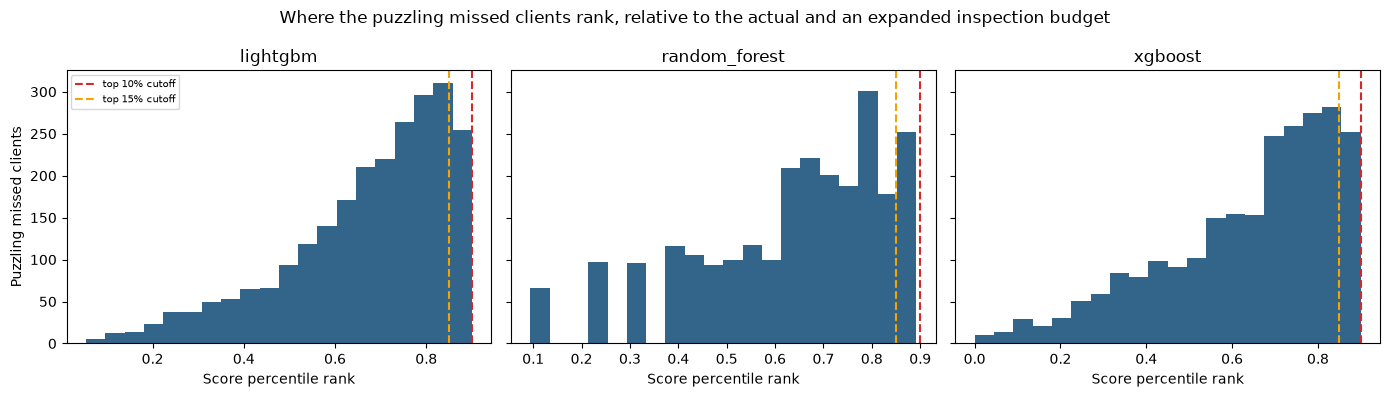

In [14]:
print("Each model's own top-10% score threshold (Step 4):")
for name in model_names:
    print(f"  {name}: {thresholds[name]:.4f}")

puzzling_missed = missed_by_all[missed_by_all["history_bucket"] == "long history (unexplained)"]
print(f"\n{len(puzzling_missed)} clients missed by all 3 models despite a long invoice history -- "
      "the genuinely puzzling subset carried into Steps 12-13.")

EXPANDED_SHARE = 0.15  # "would a slightly larger inspection budget have caught them?"

def flagged_at_share(proba, share):
    kk = int(np.ceil(share * len(proba)))
    cutoff = np.sort(proba)[::-1][kk - 1]
    return proba >= cutoff

near_miss_by_model = pd.DataFrame(
    {name: flagged_at_share(oof_probas[name], EXPANDED_SHARE)[puzzling_missed.index] for name in model_names},
    index=puzzling_missed.index,
)
near_miss_any = near_miss_by_model.any(axis=1)
print(f"\nWould be flagged by at least one model at an expanded top-{EXPANDED_SHARE:.0%} inspection budget: "
      f"{int(near_miss_any.sum())} ({near_miss_any.mean():.1%})")
print(f"Still missed by every model even at top-{EXPANDED_SHARE:.0%}: "
      f"{int((~near_miss_any).sum())} ({(~near_miss_any).mean():.1%})")

fig, axes = plt.subplots(1, len(model_names), figsize=(14, 4), sharey=True)
for ax, name in zip(axes, model_names):
    percentile_rank = pd.Series(oof_probas[name]).rank(pct=True)
    percentile_rank.loc[puzzling_missed.index].plot(kind="hist", bins=20, ax=ax, color="#33658A")
    ax.axvline(1 - TOP_K_SHARE, color="#D62828", linestyle="--", label=f"top {TOP_K_SHARE:.0%} cutoff")
    ax.axvline(1 - EXPANDED_SHARE, color="#F4A300", linestyle="--", label=f"top {EXPANDED_SHARE:.0%} cutoff")
    ax.set(title=name, xlabel="Score percentile rank")
axes[0].set_ylabel("Puzzling missed clients")
axes[0].legend(fontsize=7)
fig.suptitle("Where the puzzling missed clients rank, relative to the actual and an expanded inspection budget")
plt.tight_layout()
plt.show()

## Step 11 — What does the missed-by-all group look like on the features the model never sees?

`train_client_features.csv` carries 55 columns; the model's 15-input contract uses 15 of them.
The other ~40 were computed in `01_eda.ipynb` and postponed for later work (raw totals/maxima
instead of the rate-based versions actually used, tenure, alternative median-based meter-sequence
summaries, and a `months_number`-derived group `01_eda.ipynb` already flagged as unreliable due
to implausible values -- that unreliable group is excluded here to avoid restating a known
data-quality artifact as a new finding; the tenure columns are kept but carry the same
`creation_date`-reliability caveat `01_eda.ipynb` already raised).

Comparing non-fraud, caught-by-all-3, and missed-by-all-3 clients on the remaining unused columns
surfaces candidate differentiators nobody's looked at yet. Run twice: unrestricted (which will
mostly just re-detect the short-history confound, since missed-fraud skews short-history) and
restricted to Step 10's long-history-unexplained subset only, which isolates genuinely new signal
from the already-known one.

Unrestricted -- missed-by-all-3 vs. non-fraud, ranked by |effect size| (median gap / non-fraud IQR):


,non-fraud_median,missed by all 3_median,effect_size
gaz_invoice_count,0.0,10.0,0.476190
index_delta_max,1282.0,1865.0,0.366897
total_consumption_max,1284.0,1868.0,0.366604
total_consumption_sum,11557.0,16643.0,0.260100
index_delta_sum,11233.0,16061.0,0.250441
submission_transition_count,27.0,35.0,0.210526
invoice_gap_count,28.0,36.0,0.205128
row_count,29.0,37.0,0.205128



History-controlled (long-history clients only) -- missed-by-all-3 vs. non-fraud:


,non-fraud_median,missed by all 3_median,effect_size
total_consumption_max,1471.000000,1912.000000,0.280534
index_delta_max,1469.000000,1905.500000,0.278558
gaz_invoice_count,7.000000,12.000000,0.200000
invoice_frequency_per_year,3.609582,4.088049,0.184147
backward_submission_count,3.000000,4.000000,0.142857
median_submission_gap_days,121.500000,122.000000,0.125000
total_consumption_sum,15490.000000,17786.500000,0.124418
mean_index_delta,402.085106,445.357143,0.116895


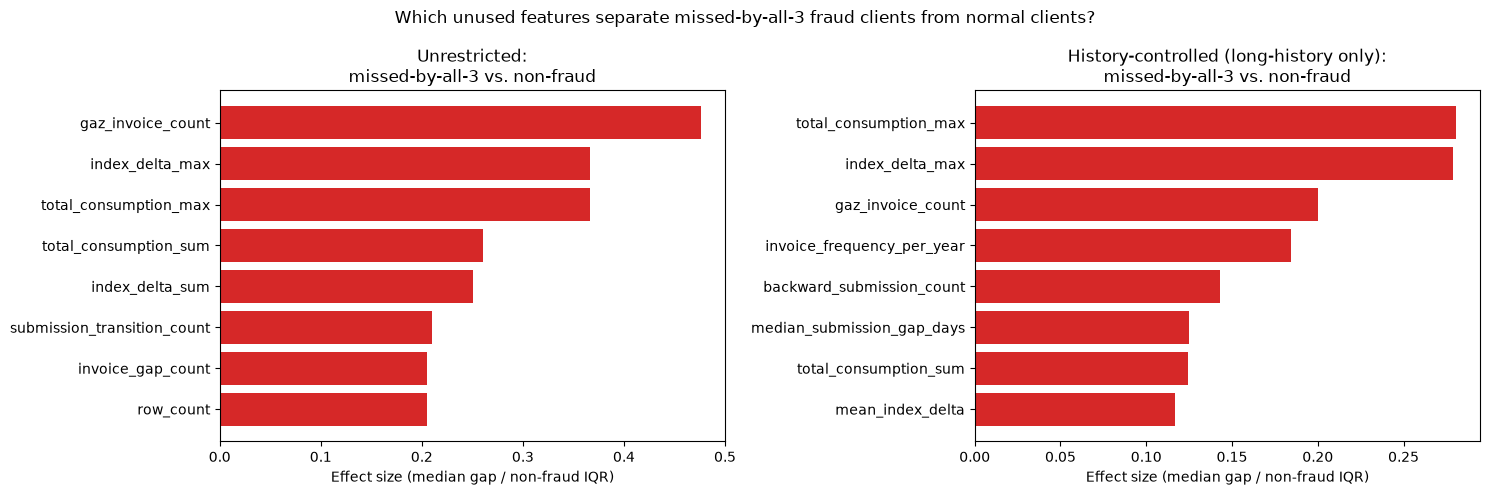

In [15]:
candidate_columns = [
    "total_consumption_sum", "total_consumption_max",
    "index_delta_sum", "index_delta_min", "index_delta_max", "mean_index_delta",
    "zero_consumption_count", "elec_invoice_count", "gaz_invoice_count",
    "backwards_index_count", "invoice_gap_count", "max_invoice_gap_days",
    "invoice_frequency_per_year", "customer_tenure_days_at_last_invoice", "has_negative_tenure",
    "submission_transition_count", "mean_submission_index_delta", "median_submission_index_delta",
    "median_monthly_submission_index_delta", "median_submission_gap_days",
    "backward_submission_count", "reconciliation_gap_abs_sum", "reconciliation_gap_abs_max",
    "row_count",
]
# Deliberately excluded: the months_number-derived billing-period group 01_eda.ipynb already
# flagged as unreliable (months_sum, valid_billing_invoice_count, billed_months_sum,
# four_month_bill_count, mean_months, mean_billing_months, four_month_bill_rate,
# months_outlier_count, index_delta_valid_months_sum, mean_index_delta_per_billed_month) --
# re-surfacing those here would restate a known data-quality artifact, not a new finding.
# customer_tenure_days_at_last_invoice/has_negative_tenure inherit the same unreliable
# creation_date 01_eda.ipynb flagged (negative for 397 clients, after-first-invoice for 8,748) --
# kept in the scan, but read any finding on them with that caveat in mind.

scan_group = pd.Series(pd.NA, index=analysis.index, dtype="object")
scan_group[analysis["target"] == 0] = "non-fraud"
scan_group[analysis["agreement"] == "caught by all 3"] = "caught by all 3"
scan_group[analysis["agreement"] == "missed by all 3"] = "missed by all 3"
analysis["scan_group"] = scan_group

def ranked_effect_sizes(frame, columns, group_a, group_b):
    # Cast to float first -- has_negative_tenure is bool, and pandas' groupby.quantile()
    # rejects bool dtype outright.
    numeric = frame[columns].astype(float)
    grouped = numeric.groupby(frame["scan_group"])
    medians = grouped.median()
    q1 = grouped.quantile(0.25)
    q3 = grouped.quantile(0.75)
    baseline_iqr = (q3.loc[group_a] - q1.loc[group_a]).replace(0, np.nan)
    effect = (medians.loc[group_b] - medians.loc[group_a]) / baseline_iqr
    return pd.DataFrame({
        f"{group_a}_median": medians.loc[group_a],
        f"{group_b}_median": medians.loc[group_b],
        "effect_size": effect,
    }).reindex(effect.abs().sort_values(ascending=False).index)

unrestricted = ranked_effect_sizes(analysis, candidate_columns, "non-fraud", "missed by all 3")
print("Unrestricted -- missed-by-all-3 vs. non-fraud, ranked by |effect size| (median gap / non-fraud IQR):")
display(unrestricted.head(8))

history_controlled_frame = analysis[analysis["history_bucket"] == "long history (unexplained)"]
controlled_result = ranked_effect_sizes(history_controlled_frame, candidate_columns, "non-fraud", "missed by all 3")
print("\nHistory-controlled (long-history clients only) -- missed-by-all-3 vs. non-fraud:")
display(controlled_result.head(8))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, title, result in [
    (axes[0], "Unrestricted", unrestricted),
    (axes[1], "History-controlled (long-history only)", controlled_result),
]:
    top = result.head(8).iloc[::-1]
    colors = ["#D62828" if v > 0 else "#33658A" for v in top["effect_size"]]
    ax.barh(top.index.astype(str), top["effect_size"], color=colors)
    ax.set(title=f"{title}:\nmissed-by-all-3 vs. non-fraud", xlabel="Effect size (median gap / non-fraud IQR)")
fig.suptitle("Which unused features separate missed-by-all-3 fraud clients from normal clients?")
plt.tight_layout()
plt.show()

### The "quiet fraud client" hypothesis

`01_eda.ipynb` already noted that fraud and non-fraud clients look nearly identical on *median*
monthly index delta (67.9 vs. 68.5) while the *mean* differs a lot (129.1 vs. 106.1) -- consistent
with a smaller number of unusually large changes driving the association, not every invoice.
`mean_monthly_submission_index_delta` is the version in the model; the median-based versions are
not. This checks whether that same mean/median gap specifically explains the model's blind spot:
does the missed-by-all group look like the "quiet" end of that distribution?

Mean-based (in the model) vs. median-based (not in the model) submission-delta features, by group:


,mean_monthly_submission_index_delta,median_monthly_submission_index_delta,median_submission_index_delta
scan_group,,,
non-fraud,106.281567,68.485241,309.5
caught by all 3,119.339987,64.745397,282.0
missed by all 3,127.450070,67.986947,314.0


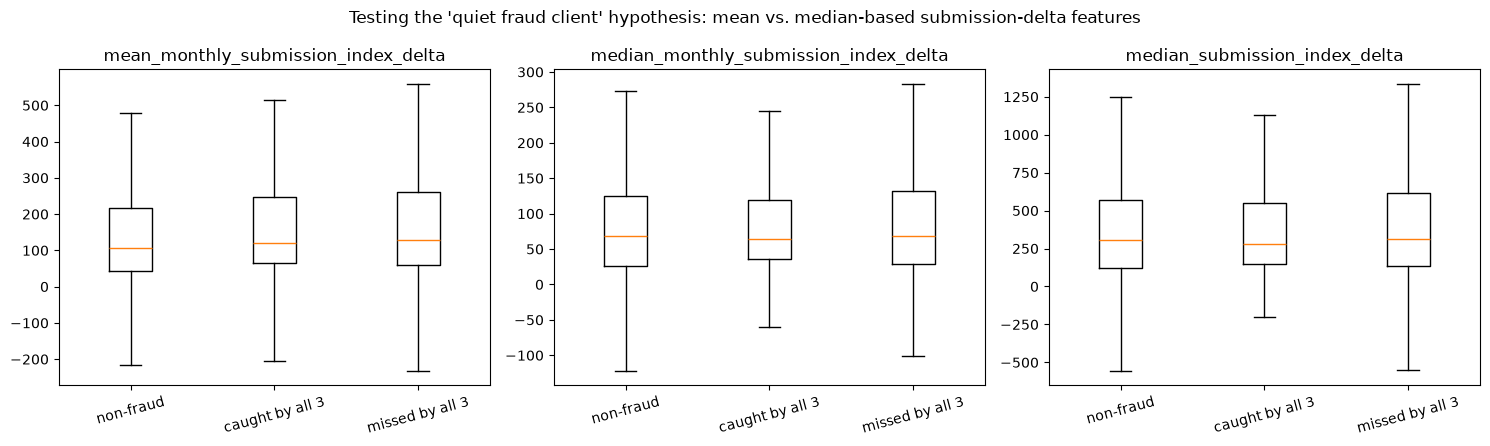

In [16]:
submission_cols = [
    "mean_monthly_submission_index_delta",  # in the model
    "median_monthly_submission_index_delta",  # not in the model
    "median_submission_index_delta",  # not in the model
]
group_order = ["non-fraud", "caught by all 3", "missed by all 3"]

mean_vs_median = analysis.groupby("scan_group")[submission_cols].median().reindex(group_order)
print("Mean-based (in the model) vs. median-based (not in the model) submission-delta features, by group:")
display(mean_vs_median)

fig, axes = plt.subplots(1, len(submission_cols), figsize=(15, 4.5))
for ax, col in zip(axes, submission_cols):
    plot_data = [analysis.loc[analysis["scan_group"] == g, col].dropna() for g in group_order]
    ax.boxplot(plot_data, tick_labels=group_order, showfliers=False)
    ax.set(title=col)
    ax.tick_params(axis="x", rotation=15)
fig.suptitle("Testing the 'quiet fraud client' hypothesis: mean vs. median-based submission-delta features")
plt.tight_layout()
plt.show()

## Step 12 — Is the missed-by-all group hiding in the imputed feature gap?

4,270 train clients have no usable positive-day meter transition, so
`mean_monthly_submission_index_delta` and `backward_submission_rate` are missing for them --
the model pipeline silently median-imputes those clients at fit time. If missed-by-all-3 fraud
clients disproportionately fall in this group, the model isn't just weak on them, it's scoring
them as generically average by construction. The key check is whether this holds up even among
*long-history* clients (an independent blind spot) or is fully explained by short history (the
same story restated).

Clients missing the meter-transition-based features (train set): 4,270
Non-fraud missing rate (baseline): 4.1%



,missing_rate_%
agreement,
caught by all 3,0.0
missed by 1 of 3,0.0
missed by 2 of 3,0.1
missed by all 3,1.9


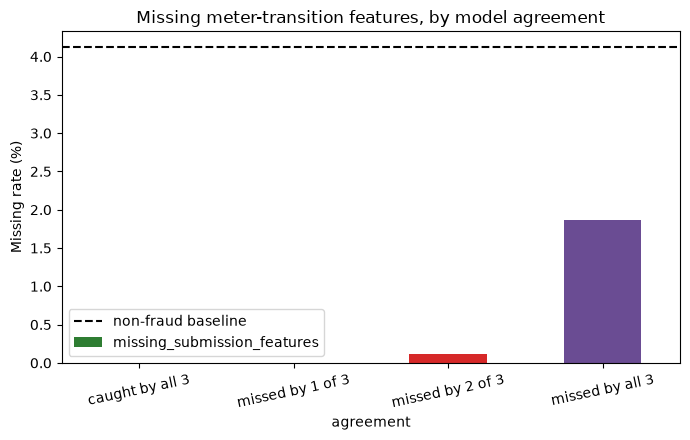


Missing-feature rate by history bucket and model agreement (fraud clients only):


agreement,caught by all 3,missed by 1 of 3,missed by 2 of 3,missed by all 3
history_bucket,,,,
long history (unexplained),0.0,0.0,0.0,0.0
short history (explained),0.0,0.0,7.7,26.2


In [17]:
analysis["missing_submission_features"] = analysis["mean_monthly_submission_index_delta"].isna()
assert (analysis["missing_submission_features"] == analysis["backward_submission_rate"].isna()).all(), \
    "Expected mean_monthly_submission_index_delta and backward_submission_rate to share one missingness mask"

non_fraud_missing_rate = analysis.loc[analysis["target"] == 0, "missing_submission_features"].mean()
missing_by_agreement = (
    analysis.loc[analysis["target"] == 1]
    .groupby("agreement")["missing_submission_features"].mean()
    .reindex(agreement_order)
)

print(f"Clients missing the meter-transition-based features (train set): "
      f"{int(analysis['missing_submission_features'].sum()):,}")
print(f"Non-fraud missing rate (baseline): {non_fraud_missing_rate:.1%}\n")
display((missing_by_agreement * 100).round(1).rename("missing_rate_%").to_frame())

fig, ax = plt.subplots(figsize=(7, 4.5))
(missing_by_agreement * 100).plot(kind="bar", ax=ax, color=[palette[c] for c in agreement_order])
ax.axhline(non_fraud_missing_rate * 100, color="black", linestyle="--", label="non-fraud baseline")
ax.set(title="Missing meter-transition features, by model agreement", ylabel="Missing rate (%)")
ax.legend()
plt.xticks(rotation=12)
plt.tight_layout()
plt.show()

missing_by_history_and_agreement = (
    analysis.loc[analysis["target"] == 1]
    .groupby(["history_bucket", "agreement"])["missing_submission_features"].mean()
    .unstack("agreement").reindex(columns=agreement_order)
)
print("\nMissing-feature rate by history bucket and model agreement (fraud clients only):")
display((missing_by_history_and_agreement * 100).round(1))

## Step 13 — What do the genuinely puzzling clients' actual invoice histories look like?

Steps 10-12 characterize the "missed despite long history" group statistically. This step looks
at a handful of them directly: their real invoice sequences from `data/parquet/invoice_train.parquet`
(raw, per-invoice, never aggregated away), split into near-miss and confidently-scored-low examples
from Step 10.

> **Leakage note:** `counter_statue` and `reading_remarque` are shown below for these clients'
> records. Both are excluded from every trained model in this project (`01_eda.ipynb` Step 7 --
> their "unusual code" rate jumps sharply at each client's *last* invoice, more so for fraud
> clients, suggesting a later investigation/account-closure event rather than an independent
> predictor). They appear here **only** for human, qualitative inspection of these already-identified
> clients -- no model in this notebook, or anywhere in this project, trains on them.

n≈6 is illustrative, not statistical evidence -- treat this as narrative color for the
presentation, not a finding to act on directly.

In [18]:
near_miss_ids = analysis.loc[puzzling_missed.index[near_miss_any.to_numpy()], "client_id"]
confidently_wrong_ids = analysis.loc[puzzling_missed.index[(~near_miss_any).to_numpy()], "client_id"]

N_EXAMPLES_PER_GROUP = 3
near_miss_selected = near_miss_ids.astype("string").head(N_EXAMPLES_PER_GROUP).tolist()
confidently_wrong_selected = confidently_wrong_ids.astype("string").head(N_EXAMPLES_PER_GROUP).tolist()
selected_client_ids = near_miss_selected + confidently_wrong_selected
near_miss_set = set(near_miss_selected)

print(f"Selected {len(selected_client_ids)} 'missed despite long history' clients for a qualitative look: "
      f"{len(near_miss_selected)} near-miss, {len(confidently_wrong_selected)} confidently-scored-low.")

invoices = pd.read_parquet(DATA_DIR / "parquet" / "invoice_train.parquet")
invoices["client_id"] = invoices["client_id"].astype("string")
client_invoices = invoices[invoices["client_id"].isin(selected_client_ids)].copy()
client_invoices["invoice_date"] = pd.to_datetime(client_invoices["invoice_date"])
client_invoices["index_delta"] = client_invoices["new_index"] - client_invoices["old_index"]
client_invoices = client_invoices.sort_values(["client_id", "invoice_date"])
print(f"Loaded {len(client_invoices):,} raw invoice rows for the {len(selected_client_ids)} selected clients.")

inspect_invoice_columns = [
    "invoice_date", "tarif_type", "counter_type",
    "consommation_level_1", "consommation_level_2", "consommation_level_3", "consommation_level_4",
    "old_index", "new_index", "index_delta", "months_number",
]

for client_id in selected_client_ids:
    client_rows = client_invoices[client_invoices["client_id"] == client_id]
    label = "near miss" if client_id in near_miss_set else "confidently scored low"
    print(f"\n=== client {client_id} ({label}, {len(client_rows)} invoices) ===")
    display(client_rows[inspect_invoice_columns])

    for flag_col in ["counter_statue", "reading_remarque"]:
        modal_code = client_rows[flag_col].mode().iloc[0]
        last_codes = client_rows[flag_col].tail(3)
        anomalous = last_codes[last_codes != modal_code]
        if len(anomalous):
            print(f"  {flag_col}: last 3 codes {last_codes.tolist()} vs. this client's own modal code "
                  f"{modal_code!r} -- {len(anomalous)} of the last 3 differ from their own norm.")
        else:
            print(f"  {flag_col}: last 3 codes match this client's own modal code ({modal_code!r}) -- no anomaly.")

Selected 6 'missed despite long history' clients for a qualitative look: 3 near-miss, 3 confidently-scored-low.


Loaded 282 raw invoice rows for the 6 selected clients.

=== client train_Client_100435 (near miss, 68 invoices) ===


,invoice_date,tarif_type,counter_type,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,index_delta,months_number
16343,2005-12-20,40,GAZ,518,0,0,0,3369,3887,518,4
16344,2005-12-20,11,ELEC,630,0,0,0,7875,8505,630,4
16341,2006-04-27,40,GAZ,1580,0,0,0,3887,5467,1580,4
16342,2006-04-27,11,ELEC,909,0,0,0,8505,9414,909,4
16329,2006-08-23,40,GAZ,74,0,0,0,5467,5541,74,4
...,...,...,...,...,...,...,...,...,...,...,...
16383,2017-12-22,11,ELEC,787,0,0,0,46217,47004,787,4
16394,2018-04-20,11,ELEC,150,0,0,0,47668,47818,150,2
16395,2018-04-20,40,GAZ,0,0,0,0,26769,26769,0,2
16385,2018-12-26,40,GAZ,0,0,0,0,26769,26769,0,4


  counter_statue: last 3 codes match this client's own modal code ('0') -- no anomaly.
  reading_remarque: last 3 codes [8, 8, 8] vs. this client's own modal code np.int16(6) -- 3 of the last 3 differ from their own norm.

=== client train_Client_10069 (near miss, 28 invoices) ===


,invoice_date,tarif_type,counter_type,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,index_delta,months_number
24876,2014-01-28,11,ELEC,750,0,0,0,43498,44248,750,6
24877,2014-05-23,11,ELEC,351,0,0,0,44248,44599,351,4
24878,2014-05-23,40,GAZ,0,0,0,0,0,0,0,4
24869,2014-09-23,11,ELEC,388,0,0,0,44599,44987,388,4
24870,2014-09-23,40,GAZ,31,0,0,0,0,31,31,4
24871,2015-01-27,40,GAZ,7,0,0,0,63,70,7,2
24879,2015-01-27,11,ELEC,0,0,0,0,45500,45500,0,2
24874,2015-09-15,11,ELEC,854,0,0,0,45500,46354,854,8
24880,2015-09-15,40,GAZ,17,0,0,0,70,87,17,8
24881,2016-01-26,11,ELEC,643,0,0,0,46354,46997,643,4


...

  counter_statue: last 3 codes match this client's own modal code ('0') -- no anomaly.
  reading_remarque: last 3 codes [9, 9, 6] vs. this client's own modal code np.int16(9) -- 1 of the last 3 differ from their own norm.

=== client train_Client_100091 (confidently scored low, 43 invoices) ===


,invoice_date,tarif_type,counter_type,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,index_delta,months_number
3262,2011-02-03,11,ELEC,361,0,0,0,3145,3506,361,2
3280,2011-06-24,11,ELEC,317,0,0,0,3506,3823,317,4
3281,2011-10-24,11,ELEC,499,0,0,0,3823,4322,499,4
3294,2012-02-24,40,GAZ,0,0,0,0,0,0,0,4
3295,2012-02-24,11,ELEC,369,0,0,0,4322,4691,369,4
3292,2012-06-22,40,GAZ,0,0,0,0,0,0,0,4
3293,2012-06-22,11,ELEC,358,0,0,0,4691,5049,358,4
3256,2012-10-24,11,ELEC,529,0,0,0,5049,5578,529,4
3259,2012-10-24,40,GAZ,0,0,0,0,0,0,0,4
3290,2013-02-28,40,GAZ,0,0,0,0,0,0,0,4


  counter_statue: last 3 codes match this client's own modal code ('0') -- no anomaly.
  reading_remarque: last 3 codes match this client's own modal code (np.int16(9)) -- no anomaly.

=== client train_Client_100109 (confidently scored low, 23 invoices) ===


,invoice_date,tarif_type,counter_type,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,index_delta,months_number
3875,2008-07-29,11,ELEC,124,0,0,0,2253,2377,124,4
3876,2008-11-26,11,ELEC,322,0,0,0,2377,2699,322,4
3886,2009-01-04,11,ELEC,323,0,0,0,2699,3022,323,4
3877,2009-11-24,11,ELEC,129,0,0,0,3718,3847,129,2
3891,2010-03-26,11,ELEC,329,0,0,0,3847,4176,329,4
3892,2010-07-21,11,ELEC,318,0,0,0,4176,4494,318,4
3893,2010-11-23,11,ELEC,405,0,0,0,4494,4899,405,4
3894,2011-03-28,11,ELEC,334,0,0,0,4899,5233,334,4
3895,2011-07-20,11,ELEC,322,0,0,0,5233,5555,322,4
3897,2012-03-21,11,ELEC,986,0,0,0,5555,6541,986,8


  counter_statue: last 3 codes match this client's own modal code ('0') -- no anomaly.
  reading_remarque: last 3 codes [9, 9, 9] vs. this client's own modal code np.int16(6) -- 3 of the last 3 differ from their own norm.


### Consumption trajectories for the same clients

A visual complement to the tables above -- does a "quiet" fraud client's consumption actually
look flat/stable over time, consistent with the mean/median-divergence hypothesis from Step 11?

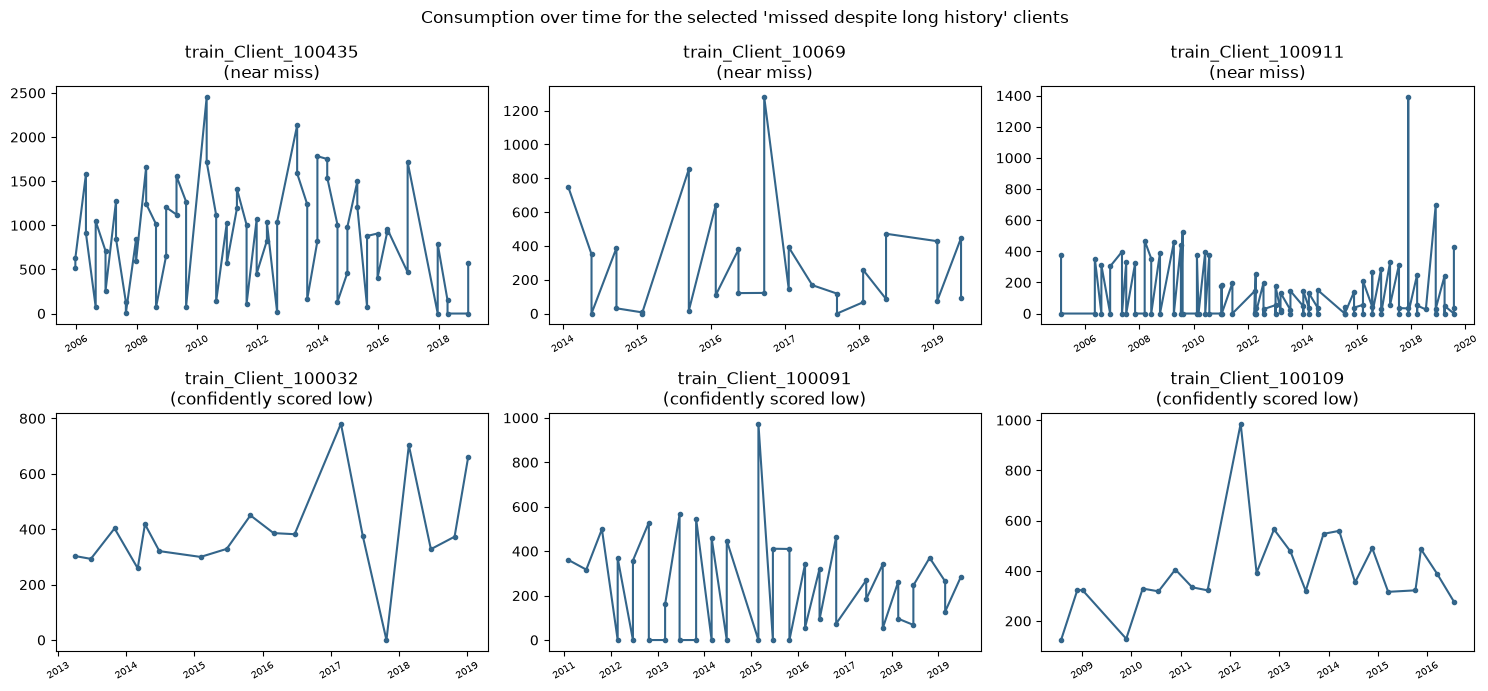

In [19]:
client_invoices["total_consumption"] = client_invoices[
    ["consommation_level_1", "consommation_level_2", "consommation_level_3", "consommation_level_4"]
].sum(axis=1)

n_selected = len(selected_client_ids)
ncols = min(3, n_selected) if n_selected else 1
nrows = int(np.ceil(n_selected / ncols)) if n_selected else 1
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), squeeze=False)
for ax, client_id in zip(axes.flat, selected_client_ids):
    client_rows = client_invoices[client_invoices["client_id"] == client_id]
    label = "near miss" if client_id in near_miss_set else "confidently scored low"
    ax.plot(client_rows["invoice_date"], client_rows["total_consumption"], marker="o", markersize=3, color="#33658A")
    ax.set(title=f"{client_id}\n({label})")
    ax.tick_params(axis="x", rotation=30, labelsize=7)
for ax in axes.flat[n_selected:]:
    ax.axis("off")
fig.suptitle("Consumption over time for the selected 'missed despite long history' clients")
plt.tight_layout()
plt.show()

## Step 14 — Synthesis table (stretch)

One compact table pulling together Steps 10-12's headline numbers, sized to paste into
`slides.md`'s error-analysis section later (that pasting is out of scope for this notebook --
see the follow-ups note at the end). Cut this step first if time is short; Steps 10-13 already
answer "what makes them different" on their own.

In [20]:
total_fraud_clients = len(fraud_positions)

synthesis_rows = [
    ("Fraud clients missed by all 3 models",
     f"{len(missed_by_all):,} ({len(missed_by_all) / total_fraud_clients:.1%} of all fraud clients)"),
    ("  - short history (explained)",
     f"{missed_split.get('short history (explained)', 0):,} "
     f"({missed_split_pct.get('short history (explained)', 0)}% of the missed group)"),
    ("  - long history (unexplained)",
     f"{missed_split.get('long history (unexplained)', 0):,} "
     f"({missed_split_pct.get('long history (unexplained)', 0)}% of the missed group)"),
    ("Long-history fraud clients still missed by every model",
     f"{long_history_missed_rate:.1%} of {len(long_history_fraud):,} long-history fraud clients"),
    ("Puzzling clients that are near-misses (expanded top-15% budget)",
     f"{int(near_miss_any.sum())} of {len(puzzling_missed)} ({near_miss_any.mean():.1%})"),
    ("Top history-controlled differentiator (unused feature)",
     f"{controlled_result.index[0]} (effect size {controlled_result['effect_size'].iloc[0]:.2f})"),
    ("Missing meter-transition features: missed-by-all-3 vs. non-fraud baseline",
     f"{missing_by_agreement.get('missed by all 3', float('nan')):.1%} vs. {non_fraud_missing_rate:.1%}"),
]
synthesis_table = pd.DataFrame(synthesis_rows, columns=["Finding", "Value"])

# Plain display() truncates long strings at display.max_colwidth (default 50 chars) and adds a
# noisy numeric index. DataFrame.style needs the optional jinja2 package, which isn't part of
# this project's dependencies -- to_html() is pandas-core-only and avoids that, so it renders
# everywhere this notebook runs without adding a new dependency for one table.
from IPython.display import HTML

with pd.option_context("display.max_colwidth", None):
    synthesis_html = synthesis_table.to_html(index=False, justify="left", escape=False, classes="synthesis-table")

display(HTML(
    "<style>table.synthesis-table td, table.synthesis-table th "
    "{ text-align: left; padding: 6px 14px; }</style>" + synthesis_html
))
print(
    "\nSized to paste into slides.md's error-analysis section -- not done automatically "
    "(see the follow-ups note at the end of this notebook)."
)

Finding,Value
Fraud clients missed by all 3 models,"2,627 (43.4% of all fraud clients)"
- short history (explained),187 (7.1% of the missed group)
- long history (unexplained),"2,440 (92.9% of the missed group)"
Long-history fraud clients still missed by every model,"41.7% of 5,849 long-history fraud clients"
Puzzling clients that are near-misses (expanded top-15% budget),614 of 2440 (25.2%)
Top history-controlled differentiator (unused feature),total_consumption_max (effect size 0.28)
Missing meter-transition features: missed-by-all-3 vs. non-fraud baseline,1.9% vs. 4.1%



Sized to paste into slides.md's error-analysis section -- not done automatically (see the follow-ups note at the end of this notebook).


## Results

> **Important:** the numerical segment, overlap, and feature-importance notes below were recorded before this notebook was aligned with the finalized 15-input contract. Rerun the cells above before presenting these detailed findings. The aggregate model comparison in `03_model_extension.ipynb` remains the current reference.

- **Confusion matrix @ top-10%**: LightGBM leads (precision 24.8%, recall 44.4%), Random Forest
  close behind (23.8% / 42.7%), XGBoost slightly further back (23.6% / 42.3%) -- consistent with
  `03_model_extension.ipynb`'s ranking.
- **`client_catg`**: all three models do noticeably *better* than their overall average on
  category 51 (the ~17%-fraud-rate segment) -- LightGBM 70.0% recall there vs. 44.4% overall --
  and noticeably *worse* on category 12 (recall 10.7-14.7%, but only 75 fraud cases, so read this
  cautiously rather than as a solid finding).
- **`disrict`**: district 63 is easier for every model (recall 55-58%) than the other three
  (35-43%), despite a mid-range fraud rate (6.5%) -- not the obvious "highest-fraud-rate" segment.
- **`region`**: real segment-robustness gap. Region 311 is easy for every model (recall
  62.6-68.0%), while regions 104 and 107 -- both with substantial fraud volume (569 and 524
  cases) -- are hard for every model (recall 24-33%). A strong overall number is hiding a
  meaningfully weaker region.
- **Invoice-count quintile -- the headline finding.** Recall for the shortest-history clients
  (1-7 invoices, 204 fraud cases) collapses to **2.0% (LightGBM), 2.9% (Random Forest), 3.4%
  (XGBoost)** -- essentially none of the fraud in this group is caught, by any model -- compared
  to 45-55% for the longest-history quintile. This is the observation-window bias the EDA flagged
  as a labeling risk, now confirmed as a real, severe *model* blind spot, not just a curiosity
  about the data.
- **Model agreement is high**: of 6,053 fraud clients, 1,746 (28.8%) are caught by all three
  models and 2,563 (42.4%) are missed by all three -- 71% of fraud clients get the *same* verdict
  from every model. Only 1,744 (28.8%) see any disagreement. False positives follow the same
  pattern: 89,089 non-fraud clients are correctly left alone by all three, and only ~13,252 are
  ever flagged by at least one.
- **Feature importance**: LightGBM and Random Forest substantially agree on what matters
  (`active_days`, `meter_count`, consumption and
  invoice-gap features dominate both top-12 lists). **XGBoost is notably different** -- its top
  features are dominated by one-hot geographic codes (`disrict_69`, `region_101`, `region_103`,
  `region_301`, `region_311`), a mechanism the other two barely use at all.

- **Step 7's scatter plots make the agreement finding visually concrete**: fraud clients form
  a clear diagonal band in every pairwise score comparison -- green ("caught by all 3") sits in
  the top-right (all scores high), purple ("missed by all 3") sits in the bottom-left (all
  scores low), and the orange/red disagreement cases fill the off-diagonal band where one model
  scores a client noticeably higher than another.
- **A nuance the segment charts surface that's easy to miss**: the *rate* of being missed is
  worst for short-history clients (the shortest quintile is ~93% purple), but the *absolute
  number* of always-missed fraud clients is actually concentrated more in the longer-history
  quintiles (24.7% of all "missed by all 3" clients come from the longest quintile vs. 7.5% from
  the shortest) -- simply because far more fraud cases exist there in total. Both are true at
  once: short-history clients are proportionally the model's biggest blind spot, but longer-
  history clients still account for more of the raw number of missed fraud cases. Worth stating
  both ways in the presentation rather than picking one.
- `client_catg`'s by-agreement chart is a good visual reminder of the sample-size caveat already
  noted: categories 12 and 51 are so small next to category 11 that their bars are barely
  visible in absolute terms -- read any category-12/51-specific finding as suggestive, not solid.

## Interpretation

- The high agreement between models (71% identical verdicts) explains why LightGBM, Random
  Forest, and XGBoost score similarly in aggregate: they're mostly finding the *same* fraud and
  missing the *same* fraud, not exploring genuinely different parts of the problem. The 2,563
  fraud clients missed by every model are the dataset's genuinely hard cases with the current
  features -- no amount of model-swapping alone is likely to catch them.
- The invoice-count collapse is the single most important finding here. A recall number like
  44% sounds usable for an inspection team, but that average is hiding a near-total blind spot
  for the newest, least-observed clients -- exactly the clients a real fraud program would most
  want early signal on. Reporting one aggregate recall number without this caveat would overstate
  the model's real-world usefulness.
- XGBoost's reliance on `disrict`/`region` one-hot codes is worth flagging as a fairness question,
  not just a technical curiosity: the EDA already cautioned that geographic fraud-rate patterns
  could partly reflect *where inspections have historically happened* rather than true fraud
  propensity (associations, not causes). XGBoost is structurally more exposed to that risk than
  LightGBM/Random Forest, which barely use geography at all -- a real consideration for model
  choice beyond raw PR-AUC.

### Next steps

- **Treat the invoice-count blind spot as the priority**, ahead of hyperparameter tuning: tuning
  a model's settings won't fix a missing-signal problem for short-history clients. Worth trying
  relative/normalized feature versions (e.g., consumption or gap features expressed per-invoice
  or per-active-day rather than as raw sums) that don't structurally require a long history to
  be informative, and stating the limitation explicitly in the presentation regardless.
- **Look closer at regions 104 and 107** before finalizing -- substantial fraud volume, poor
  recall across every model, worth understanding whether that's a genuine harder fraud pattern or
  a data/feature gap specific to those regions.
- **Try a soft (probability-averaging) ensemble of LightGBM + Random Forest** -- they share most
  of their top features and agree most often, so an ensemble is more about smoothing noise than
  combining genuinely different signals; test it against each individual model via the same CV
  scheme before adopting it. An "OR"-style union is not recommended: it would recover some of the
  1,744 disagreement cases but roughly triples the false-positive count (13,252 vs. ~8,000-8,500
  per model alone).
- **Now proceed to hyperparameter tuning of LightGBM** (the confirmed single leader from `03`),
  informed by the above -- and re-check the invoice-count quintile breakdown afterward to confirm
  tuning didn't just improve the easy majority while leaving the short-history blind spot as bad
  as before.
- **`client_catg == 12`'s weak recall** is a low-confidence finding (75 fraud cases) -- flag it,
  don't act on it without more data.

## Follow-ups outside this notebook

Written here rather than acted on -- this round of changes is scoped to `04_error_analysis.ipynb`
only.

- **`slides.md`** still shows only the stale dummy-vs-logistic-regression baseline in its
  error-analysis section. Step 14's synthesis table (if run) is sized to paste in directly once
  the deck is updated.
- **`01_eda.ipynb`'s save cell** still writes `df_train.csv`/`df_test.csv`, while
  `data/processed/` on disk holds `train_client_features.csv`/`test_client_features.csv` -- the
  names this notebook's `TRAIN_FEATURES_PATH` actually points to. Rerunning `01_eda.ipynb` with
  `SAVE_CSV_FILE=true` today would regenerate the old filenames and break this notebook's data
  load again.
- **README/CI reproducibility gap**: `pyproject.toml`/`uv.lock` already cover every dependency
  all four notebooks need (verified via `uv sync`), but `README.md` still documents the
  Docker/`quay.io/jupyter/scipy-notebook` workflow, and `.github/workflows/notebooks.yml` only
  runs notebooks 01-02 through Docker (which lacks `lightgbm`/`xgboost`/`imbalanced-learn` for
  03-04). Worth deciding which reproducible setup is canonical and aligning docs/CI to it.